# 🔍 Step 7 — SHAP Values (Explainability)

**เป้าหมาย:** อธิบายว่าโมเดลตัดสินใจอย่างไร — ทั้งในภาพรวมและรายคนไข้

---

### SHAP คืออะไร?

โมเดล LightGBM เป็น **"black box"** — บอกได้ว่า *ใครเป็นเบาหวาน* แต่ไม่บอกว่า *ทำไม*  
SHAP แก้ปัญหานี้โดยคำนวณ "contribution" ของแต่ละ feature:

```
ผลทำนาย = base_value + SHAP(Glucose) + SHAP(BMI) + SHAP(Age) + ...
```

- **SHAP > 0** → feature นี้ดัน probability ให้ **สูงขึ้น** (เสี่ยงเบาหวานมากขึ้น)
- **SHAP < 0** → feature นี้ดัน probability ให้ **ต่ำลง** (เสี่ยงน้อยลง)
- **SHAP = 0** → feature นี้ไม่มีผลสำหรับคนไข้คนนี้

### ทำไมสำคัญในทางการแพทย์?
แพทย์ต้องการรู้ว่า **"ทำไมถึงวินิจฉัยว่าเป็นเบาหวาน?"**  
ถ้าโมเดลบอกแค่ 80% โดยไม่อธิบาย → แพทย์จะไม่เชื่อและไม่นำไปใช้

## 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

shap.initjs()   # เปิดใช้ JavaScript สำหรับ interactive plots
print(f"SHAP version: {shap.__version__} ✓")

SHAP version: 0.52.0 ✓


## 2. โหลดข้อมูลและเทรนโมเดล

> SHAP ทำงานกับโมเดลโดยตรง (ไม่ผ่าน Pipeline)  
> เพื่อให้ feature names ชัดเจนใน plot เราจึงแยก preprocess ออกมา

In [2]:
df = pd.read_csv("diabetes.csv")

COLS_TO_FIX = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
FEATURE_NAMES = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                 "Insulin", "BMI", "DiabetesPedigree", "Age"]

X = df[FEATURE_NAMES].copy()
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation แบบ class-aware (จาก Step 2)
X_train_c = X_train.copy()
X_test_c  = X_test.copy()

fill_vals = {}
for col in COLS_TO_FIX:
    medians = []
    for cls in [0, 1]:
        mask = (X_train_c[col] != 0) & (y_train == cls)
        medians.append(X_train_c.loc[mask, col].median())
        X_train_c.loc[(X_train_c[col] == 0) & (y_train == cls), col] = medians[-1]
    fill_vals[col] = np.mean(medians)

for col in COLS_TO_FIX:
    X_test_c[col] = X_test_c[col].replace(0, np.nan).fillna(fill_vals[col])

# Scaling
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train_c), columns=FEATURE_NAMES)
X_test_s  = pd.DataFrame(scaler.transform(X_test_c),      columns=FEATURE_NAMES)

# เทรน LightGBM
scale = (y_train == 0).sum() / (y_train == 1).sum()
model = lgb.LGBMClassifier(
    n_estimators=340, learning_rate=0.019, num_leaves=10,
    min_child_samples=22, feature_fraction=0.60,
    bagging_fraction=0.69, bagging_freq=6,
    scale_pos_weight=scale, random_state=42, verbose=-1
)
model.fit(X_train_s, y_train)

from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test_s)[:, 1]
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Train: {len(X_train_s)} แถว | Test: {len(X_test_s)} แถว")

AUC-ROC: 0.8157
Train: 614 แถว | Test: 154 แถว


## 3. คำนวณ SHAP Values

> **TreeExplainer** เหมาะกับ tree-based models (LightGBM, XGBoost)  
> เร็วกว่า KernelExplainer มาก เพราะใช้ tree structure ช่วยคำนวณ

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_s)

# LightGBM คืน shap_values เป็น list [class_0, class_1]
# เราสนใจ class_1 (เบาหวาน)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")
print(f"  = {sv.shape[0]} คนไข้ × {sv.shape[1]} features")
print(f"\nBase value (ค่าเริ่มต้น ก่อนดู feature): {explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value:.4f}")

SHAP values shape: (154, 8)
  = 154 คนไข้ × 8 features

Base value (ค่าเริ่มต้น ก่อนดู feature): -1.2595


## 4. Global Explanation — ภาพรวมทั้งโมเดล

### 4.1 Bar Plot — Feature Importance เฉลี่ย

> แสดงว่า feature ไหน **ส่งผลต่อโมเดลมากที่สุดในภาพรวม**  
> คือค่าเฉลี่ย |SHAP| ของทุกคนไข้

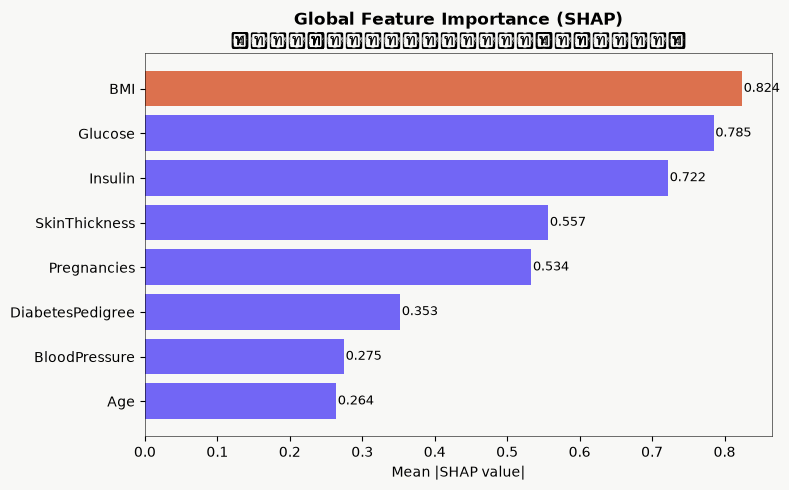

         Feature  Mean |SHAP|
             BMI     0.824421
         Glucose     0.785278
         Insulin     0.722327
   SkinThickness     0.556893
     Pregnancies     0.533568
DiabetesPedigree     0.352557
   BloodPressure     0.275019
             Age     0.264152


In [4]:
mean_abs_shap = np.abs(sv).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature":    FEATURE_NAMES,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#F8F8F6")
ax.set_facecolor("#F8F8F6")

colors = ["#D85A30" if v == mean_abs_shap.max() else "#5B4CF5"
          for v in importance_df["Mean |SHAP|"]]

bars = ax.barh(importance_df["Feature"], importance_df["Mean |SHAP|"],
               color=colors, alpha=0.85)

for bar, val in zip(bars, importance_df["Mean |SHAP|"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Mean |SHAP value|", fontsize=10)
ax.set_title("Global Feature Importance (SHAP)\nค่าเฉลี่ยของผลกระทบต่อทุกคนไข้",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
for spine in ax.spines.values(): spine.set_linewidth(0.4)

plt.tight_layout()
plt.savefig("step7_importance.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(importance_df.to_string(index=False))

### 4.2 Beeswarm Plot — ดูทิศทางด้วย

> กราฟที่ดีที่สุดสำหรับ SHAP — แสดงทั้ง **ความสำคัญ** และ **ทิศทาง**  
> แต่ละจุด = คนไข้ 1 คน  
> สีแดง = ค่า feature สูง, สีน้ำเงิน = ค่า feature ต่ำ  
> ตำแหน่ง X = SHAP value (บวก = ดันเสี่ยงขึ้น, ลบ = ดันเสี่ยงลง)

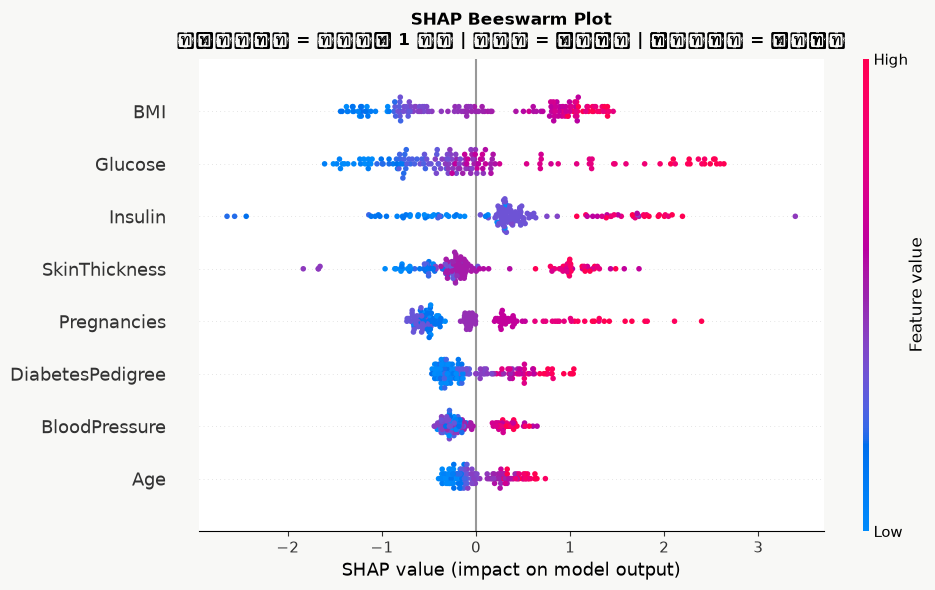

→ อ่านว่า: Glucose สูง (แดง) อยู่ด้านขวา = ดันความเสี่ยงขึ้นเสมอ


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#F8F8F6")

shap.summary_plot(
    sv,
    X_test_s,
    feature_names=FEATURE_NAMES,
    plot_type="dot",
    show=False,
    plot_size=None
)

plt.title("SHAP Beeswarm Plot\nแต่ละจุด = คนไข้ 1 คน | แดง = ค่าสูง | น้ำเงิน = ค่าต่ำ",
          fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("step7_beeswarm.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F8F6")
plt.show()
print("→ อ่านว่า: Glucose สูง (แดง) อยู่ด้านขวา = ดันความเสี่ยงขึ้นเสมอ")

## 5. Individual Explanation — อธิบายรายคนไข้

> นี่คือสิ่งที่มีคุณค่าสูงสุดในทางการแพทย์  
> แพทย์สามารถถามว่า "ทำไมคนไข้คนนี้ถึงเสี่ยง?" และได้คำตอบที่เข้าใจได้

### 5.1 เลือกคนไข้ที่น่าสนใจ

In [6]:
y_test_arr   = y_test.values
probs        = model.predict_proba(X_test_s)[:, 1]

# คนที่โมเดลเชื่อมั่นมากว่าเป็นเบาหวาน
idx_high_risk = np.argmax(probs * (y_test_arr == 1))

# คนที่โมเดลเชื่อมั่นมากว่าไม่เป็น
idx_low_risk  = np.argmax((1 - probs) * (y_test_arr == 0))

# คนที่โมเดลไม่แน่ใจ (prob ใกล้ 0.5)
idx_uncertain = np.argmin(np.abs(probs - 0.5))

cases = {
    "High Risk  (เสี่ยงสูง)": idx_high_risk,
    "Low Risk   (เสี่ยงต่ำ)": idx_low_risk,
    "Uncertain  (ไม่แน่ใจ)": idx_uncertain,
}

print(f"{'Case':<28} {'Prob':>7}  {'จริง':>6}  Glucose   BMI   Age")
print("-" * 65)
for name, idx in cases.items():
    row = X_test_s.iloc[idx]
    # แปลงกลับสเกลเดิม
    orig = X_test_c.iloc[idx]
    actual = "เบาหวาน" if y_test_arr[idx] == 1 else "ไม่เป็น"
    print(f"{name:<28} {probs[idx]:>6.1%}  {actual:>7}  "
          f"{orig['Glucose']:>6.0f}  {orig['BMI']:>5.1f}  {orig['Age']:>3.0f}")

Case                            Prob    จริง  Glucose   BMI   Age
-----------------------------------------------------------------
High Risk  (เสี่ยงสูง)        98.6%  เบาหวาน     148   42.0   56
Low Risk   (เสี่ยงต่ำ)         0.2%  ไม่เป็น      82   18.0   23
Uncertain  (ไม่แน่ใจ)         49.8%  เบาหวาน     175   18.0   21


### 5.2 Waterfall Plot — อธิบายคนไข้ทีละคน

> กราฟนี้อ่านจากล่างขึ้นบน:  
> เริ่มจาก **base value** (ค่าเฉลี่ยของโมเดล)  
> แต่ละ feature ดันขึ้น (แดง) หรือลง (น้ำเงิน)  
> สุดท้ายได้ **final prediction** ของคนไข้คนนี้

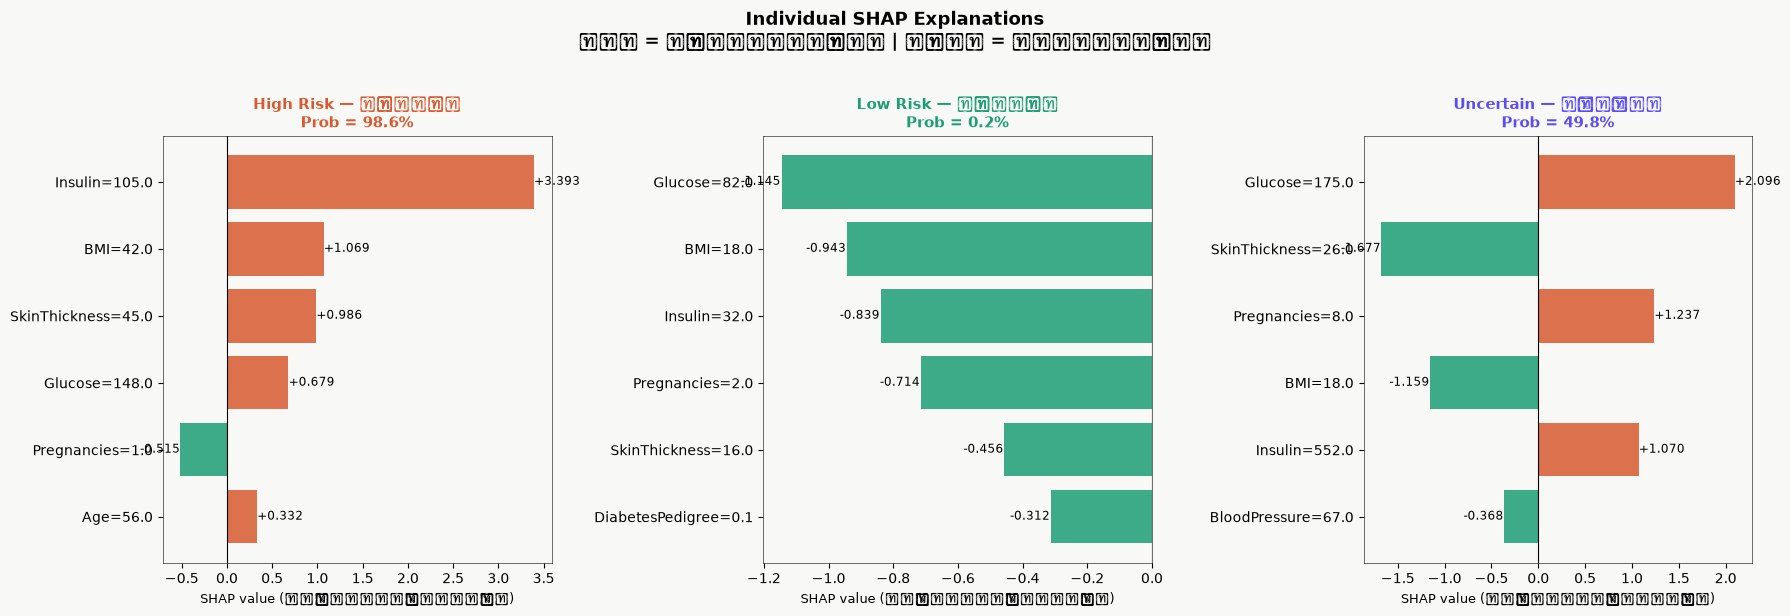

In [7]:
base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, list) \
           else explainer.expected_value

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#F8F8F6")

titles = ["High Risk — เสี่ยงสูง", "Low Risk — เสี่ยงต่ำ", "Uncertain — ไม่แน่ใจ"]
colors_title = ["#D85A30", "#1D9E75", "#5B4CF5"]

for ax, (name, idx), title, tc in zip(axes, cases.items(), titles, colors_title):
    shap_row = sv[idx]
    feat_vals = X_test_c.iloc[idx]   # ค่าดิบ (ไม่ scaled) เพื่อให้อ่านง่าย

    # เรียงตามขนาด SHAP
    order     = np.argsort(np.abs(shap_row))[::-1][:6]   # top 6
    feat_show = [f"{FEATURE_NAMES[i]}={feat_vals[FEATURE_NAMES[i]]:.1f}" for i in order]
    shap_show = shap_row[order]

    bar_colors = ["#D85A30" if v > 0 else "#1D9E75" for v in shap_show]
    bars = ax.barh(feat_show[::-1], shap_show[::-1], color=bar_colors[::-1], alpha=0.85)

    for bar, val in zip(bars, shap_show[::-1]):
        offset = 0.003 if val >= 0 else -0.003
        ha = "left" if val >= 0 else "right"
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", ha=ha, fontsize=8.5)

    ax.axvline(0, color="black", linewidth=0.8)
    prob_val = probs[idx]
    ax.set_title(f"{title}\nProb = {prob_val:.1%}",
                 fontsize=11, fontweight="bold", color=tc, pad=6)
    ax.set_xlabel("SHAP value (ผลต่อความน่าจะเป็น)", fontsize=9)
    ax.set_facecolor("#F8F8F6")
    for spine in ax.spines.values(): spine.set_linewidth(0.4)

fig.suptitle("Individual SHAP Explanations\nแดง = เพิ่มความเสี่ยง | เขียว = ลดความเสี่ยง",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("step7_individual.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

### 5.3 Dependence Plot — ความสัมพันธ์ระหว่าง Feature กับ SHAP

> บอกว่า feature มีผลต่อโมเดล **อย่างไรตลอดช่วงค่า**  
> เช่น Glucose เริ่มส่งผลบวก (เพิ่มเสี่ยง) ที่ค่าเท่าไหร่?

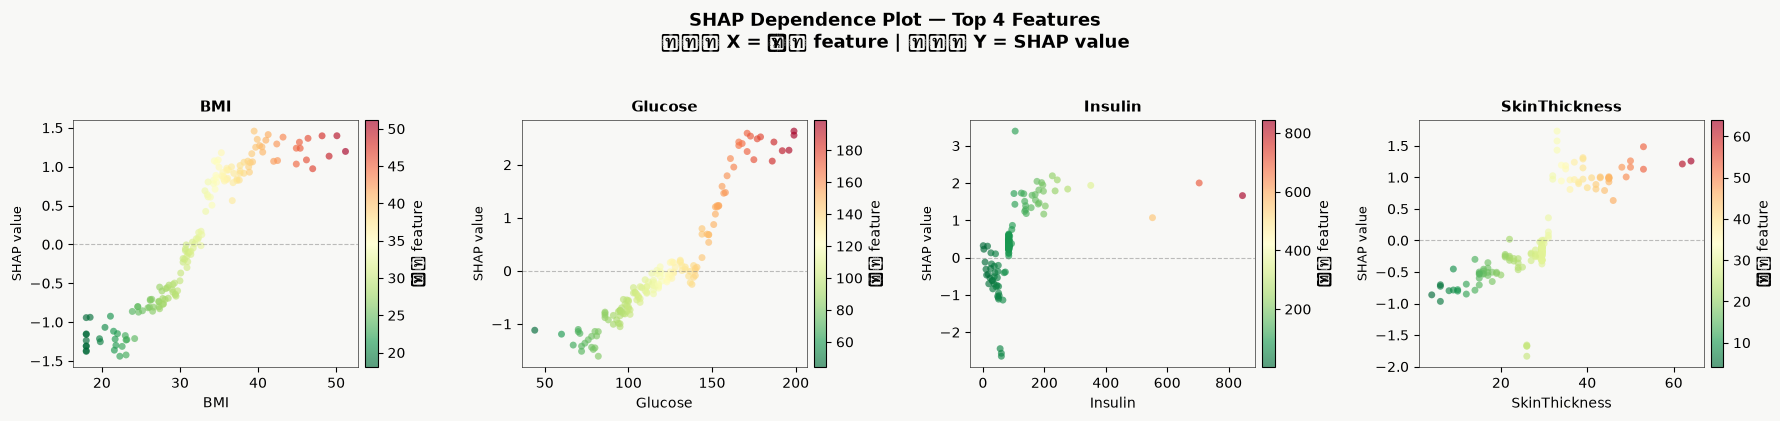

→ เส้นประแนวนอน (SHAP=0) = จุดที่ feature เริ่มส่งผลบวก/ลบ


In [8]:
top_features = importance_df["Feature"].values[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor("#F8F8F6")

for ax, feat in zip(axes, top_features):
    feat_idx   = FEATURE_NAMES.index(feat)
    feat_vals  = X_test_c[feat].values        # ค่าดิบ (ไม่ scaled)
    shap_col   = sv[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_col,
                    c=feat_vals, cmap="RdYlGn_r",
                    alpha=0.65, s=25, edgecolors="none")
    ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.set_title(f"{feat}", fontsize=11, fontweight="bold")
    ax.set_facecolor("#F8F8F6")
    plt.colorbar(sc, ax=ax, label="ค่า feature", pad=0.02)
    for spine in ax.spines.values(): spine.set_linewidth(0.4)

fig.suptitle("SHAP Dependence Plot — Top 4 Features\nแกน X = ค่า feature | แกน Y = SHAP value",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("step7_dependence.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("→ เส้นประแนวนอน (SHAP=0) = จุดที่ feature เริ่มส่งผลบวก/ลบ")

## 6. สรุปสิ่งที่อ่านได้จาก SHAP

In [9]:
print("=" * 60)
print("  สรุปสิ่งที่ SHAP บอกเราเกี่ยวกับโมเดลนี้")
print("=" * 60)

print(f"\n1. Feature ที่สำคัญที่สุด (Global):")
for _, row in importance_df.head(3).iterrows():
    print(f"   {row['Feature']:<20} Mean|SHAP| = {row['Mean |SHAP|']:.4f}")

print(f"\n2. คนไข้ High Risk:")
idx = idx_high_risk
shap_row = sv[idx]
top3_idx = np.argsort(np.abs(shap_row))[::-1][:3]
for i in top3_idx:
    direction = "↑ เพิ่มเสี่ยง" if shap_row[i] > 0 else "↓ ลดเสี่ยง"
    orig_val  = X_test_c.iloc[idx][FEATURE_NAMES[i]]
    print(f"   {FEATURE_NAMES[i]:<20} = {orig_val:.1f}  →  SHAP {shap_row[i]:+.3f}  {direction}")

print(f"\n3. คนไข้ Low Risk:")
idx = idx_low_risk
shap_row = sv[idx]
top3_idx = np.argsort(np.abs(shap_row))[::-1][:3]
for i in top3_idx:
    direction = "↑ เพิ่มเสี่ยง" if shap_row[i] > 0 else "↓ ลดเสี่ยง"
    orig_val  = X_test_c.iloc[idx][FEATURE_NAMES[i]]
    print(f"   {FEATURE_NAMES[i]:<20} = {orig_val:.1f}  →  SHAP {shap_row[i]:+.3f}  {direction}")

print("\n" + "=" * 60)

  สรุปสิ่งที่ SHAP บอกเราเกี่ยวกับโมเดลนี้

1. Feature ที่สำคัญที่สุด (Global):
   BMI                  Mean|SHAP| = 0.8244
   Glucose              Mean|SHAP| = 0.7853
   Insulin              Mean|SHAP| = 0.7223

2. คนไข้ High Risk:
   Insulin              = 105.0  →  SHAP +3.393  ↑ เพิ่มเสี่ยง
   BMI                  = 42.0  →  SHAP +1.069  ↑ เพิ่มเสี่ยง
   SkinThickness        = 45.0  →  SHAP +0.986  ↑ เพิ่มเสี่ยง

3. คนไข้ Low Risk:
   Glucose              = 82.0  →  SHAP -1.145  ↓ ลดเสี่ยง
   BMI                  = 18.0  →  SHAP -0.943  ↓ ลดเสี่ยง
   Insulin              = 32.0  →  SHAP -0.839  ↓ ลดเสี่ยง



## ✅ สรุป Step 7

### กราฟที่สร้าง

| กราฟ | อ่านว่า |
|---|---|
| **Bar Plot** | feature ไหนสำคัญสุดในภาพรวม |
| **Beeswarm Plot** | feature ดันเสี่ยง ↑ หรือ ↓ และค่าสูง/ต่ำมีผลอย่างไร |
| **Waterfall Plot** | อธิบายรายคนไข้ว่า feature ไหนดันผลทำนาย |
| **Dependence Plot** | ความสัมพันธ์แบบ non-linear ระหว่าง feature กับ SHAP |

### Concept ที่เรียน

| Concept | ความหมาย |
|---|---|
| **SHAP value** | contribution ของแต่ละ feature ต่อผลทำนาย |
| **Base value** | ค่าเฉลี่ย prediction ของโมเดลทั้งหมด |
| **TreeExplainer** | คำนวณ SHAP เร็วสำหรับ tree-based models |
| **Global vs Local** | ภาพรวมทั้งโมเดล vs อธิบายรายคน |

---
> **ประโยชน์จริงในโรงพยาบาล:** แพทย์ดูได้ว่า *"คนไข้คนนี้เสี่ยงเพราะ Glucose สูงและ BMI มาก"*  
> ทำให้โมเดล AI น่าเชื่อถือและนำไปใช้ได้จริงในทางคลินิก